In [11]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Adaptive scheduling: measure $T_{on}$ and $T_{off}$ from the tumor itself

In `SI_strategies_with_clonal_selection.ipynb` the timescale-separation (TST) schedule uses a **fixed** off-duration ($T_{off}=10$) and an analytic net-decay-optimal on-duration, both derived purely from the fast $A,B$ kinetics — so total tumor burden trends *downward* cycle over cycle (until clonal selection eventually relapses it).

Here we use a fully *simulation-driven* schedule, closer to the *containment* philosophy of adaptive therapy: on the **first** cycle we **measure both half-durations directly from the dynamics** — $T_{on}$ is how long treatment takes to drive total burden down to **50%** of its initial size, and $T_{off}$ is how long it then takes to regrow back to **100%**. We **freeze** both values and reuse them as a fixed $(T_{on}, T_{off})$ schedule for every subsequent cycle.

Scenario: fully resistant clone (`cr_sensitivity=0`), $r_s=0.05$, $r_r=0.03$ — the regime from the SI notebook where clonal selection actually drives a relapse.

In [12]:
from rpa_control.models import ABCClonalModel, b1, b1_on, A_ss, B_ss
from rpa_control import simulation

# --- AB kinetics: analytic net-decay-optimal on-duration -- kept as a REFERENCE only;
#     T_on is now measured by simulation in Step 1 (treat until 50% of baseline) ---
a1_, b2_, mu_, c2_ = 1.0, 2.0, 1.0, 1.0        # AB/kill parameters of the ABC model
disc = b2_**2 - 4 * a1_ * b1_on
lam1 = (-b2_ + np.sqrt(disc)) / 2
lam2 = (-b2_ - np.sqrt(disc)) / 2
K1   = b2_ * mu_ * (b1_on / b1 - 1) / (lam1 - lam2)

def decay_analytic(Ton):
    """Analytic cumulative log-decay of Cs over one on-phase (independent of Cr)."""
    Ton = np.asarray(Ton)
    return -c2_ * K1 * (
        np.exp(lam1 * Ton) / lam1 - np.exp(lam2 * Ton) / lam2 - 1 / lam1 + 1 / lam2
    )

r_s_slow  = 0.05      # slow tumor growth (>> AB recovery timescale), as in the SI notebook
r_r_slow  = 0.03
T_off_ref = 10.0      # the *old* fixed off-duration -- kept only as a reference below

Ton_arr = np.linspace(0.01, 40, 2000)
net_arr = decay_analytic(Ton_arr) - r_s_slow * (Ton_arr + T_off_ref)
Ton_analytic = Ton_arr[np.argmax(net_arr)]

print(f'A_ss={A_ss:.3f}  B_ss={B_ss:.3f}  b1(off)={b1}  b1_on(on)={b1_on}')
print(f'analytic net-decay optimum Ton_analytic = {Ton_analytic:.3f}  (reference; T_on measured below)')

A_ss=2.000  B_ss=1.000  b1(off)=1.0  b1_on(on)=0.5
analytic net-decay optimum Ton_analytic = 9.052  (reference; T_on measured below)


In [13]:
from scipy.optimize import brentq

def plot_abc_clonal_run(t, y, on_ranges, title='', thresholds=None):
    """One figure: A, B, {Cs, Cr, total} on shared log axes, and resistant fraction.
    on_ranges: list of (t_start, t_end) treatment-on intervals to shade."""
    A, B, Cs, Cr = y
    total = Cs + Cr
    resist_frac = Cr / total

    fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True,
                             gridspec_kw={'hspace': 0.1, 'height_ratios': [1, 1, 1.6, 1]})
    for ax in axes:
        for t0, t1 in on_ranges:
            ax.axvspan(t0, t1, color='lightgray', alpha=0.4, lw=0)
        sns.despine(ax=ax)

    axes[0].plot(t, A, color='C1', lw=1.4)
    axes[0].set_ylabel('$A$', fontsize=9)

    axes[1].plot(t, B, color='C0', lw=1.4)
    axes[1].axhline(mu_, color='C0', ls='--', lw=0.9, alpha=0.5, label=r'$\mu$')
    axes[1].set_ylabel('$B$', fontsize=9)
    axes[1].legend(fontsize=7.5, frameon=False, loc='lower right')

    axes[2].plot(t, Cs, label='$C_s$ (sensitive)')
    axes[2].plot(t, Cr, label='$C_r$ (resistant)')
    axes[2].plot(t, total, color='k', ls='--', lw=1.2, label='total')
    if thresholds:
        for label, val in thresholds:
            axes[2].axhline(val, color='0.4', ls=':', lw=1.2, alpha=0.85, label=label)
    axes[2].set_ylabel('population')
    axes[2].set_yscale('log')
    axes[2].legend(fontsize=7.5, frameon=False, loc='center right')

    axes[3].plot(t, resist_frac, color='C3')
    axes[3].set_ylabel('resistant\nfraction')
    axes[3].set_ylim(0, 1)
    axes[3].set_xlabel('time')

    axes[0].set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()


def periodic_on_ranges(Ton, Toff, n_cycles):
    return [(c * (Ton + Toff), c * (Ton + Toff) + Ton) for c in range(n_cycles)]


def time_to_progression(t, total, baseline, multiple=2.0):
    """First time `total` crosses `multiple` x `baseline`, or None if it never does."""
    threshold = multiple * baseline
    above = total >= threshold
    if not np.any(above):
        return None
    idx = np.argmax(above)
    if idx == 0:
        return t[0]
    f = lambda tt: np.interp(tt, t, total) - threshold
    return brentq(f, t[idx - 1], t[idx])

burden_fn = lambda y: y[2] + y[3]   # total tumor size Cs + Cr

### Step 1 — measure $T_{on}$ and $T_{off}$ on the first cycle

Integrate the on-phase with a `solve_ivp` terminal **event** that fires the instant total burden $C_s+C_r$ falls to **50%** of baseline — that time is $T_{on}$. Continue from that state through the off-phase with a second event at the upward crossing of baseline — that time is the recovery $T_{off}$. Both are measured on this first cycle (while $C_r$ is still a negligible seed), then **frozen** and reused for every subsequent cycle.

In [14]:
# Scenario A: resistant clone fully immune to the drug (cr_sensitivity=0) --
# the regime where clonal selection actually drives a relapse.
model = ABCClonalModel(r_s=r_s_slow, r_r=r_r_slow, carrying_capacity=1000.0, cr_sensitivity=0.0)

Cs0, Cr0 = 10.0, 0.01                     # rare pre-existing resistant seed (1/1000th of Cs0)
y0       = np.array([A_ss, B_ss, Cs0, Cr0])
baseline = Cs0 + Cr0                       # 100% of the initial tumor size

f_on  = model.get_f({'b1': b1_on})
f_off = model.get_f({'b1': b1})

# --- T_on: treat (on-phase) until total burden falls to 50% of baseline ---
def event_halfkill(t, y):
    return (y[2] + y[3]) - 0.5 * baseline
event_halfkill.terminal  = True
event_halfkill.direction = -1             # trigger on the downward crossing

sol_on = solve_ivp(f_on, (0, 500.0), y0, events=event_halfkill,
                   method='Radau', dense_output=True, rtol=1e-8, atol=1e-10, max_step=0.5)
assert sol_on.t_events[0].size > 0, "treatment never drove total down to 50% of baseline"
Ton_opt        = float(sol_on.t_events[0][0])   # simulated on-duration (treat to 50%)
y_after_on     = sol_on.y[:, -1]
total_after_on = y_after_on[2] + y_after_on[3]

# --- T_off: from that state, integrate the off-phase until total regrows to baseline ---
def event_recover(t, y):
    return (y[2] + y[3]) - baseline
event_recover.terminal  = True
event_recover.direction = 1               # trigger on the upward crossing

sol_off = solve_ivp(f_off, (0, 2000.0), y_after_on, events=event_recover,
                    method='Radau', dense_output=True, rtol=1e-8, atol=1e-10, max_step=0.5)
assert sol_off.t_events[0].size > 0, "tumor never regrew to baseline within the window"
T_off_recovery = float(sol_off.t_events[0][0])

print(f'T_on  (treat down to 50% of baseline) = {Ton_opt:.3f}   '
      f'(analytic net-decay optimum was {Ton_analytic:.3f})')
print(f'  after on-phase: total = {total_after_on:.4f}  ({100 * total_after_on / baseline:.1f}% of baseline)')
print(f'T_off (regrow up to 100% of baseline) = {T_off_recovery:.3f}')
print(f'  cycle period = {Ton_opt + T_off_recovery:.2f}   '
      f'(vs old fixed T_off_ref={T_off_ref}: period {Ton_opt + T_off_ref:.2f})')

T_on  (treat down to 50% of baseline) = 2.406   (analytic net-decay optimum was 9.052)
  after on-phase: total = 5.0050  (50.0% of baseline)
T_off (regrow up to 100% of baseline) = 14.879
  cycle period = 17.29   (vs old fixed T_off_ref=10.0: period 12.41)


/tmp/ipykernel_2909079/2905689943.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


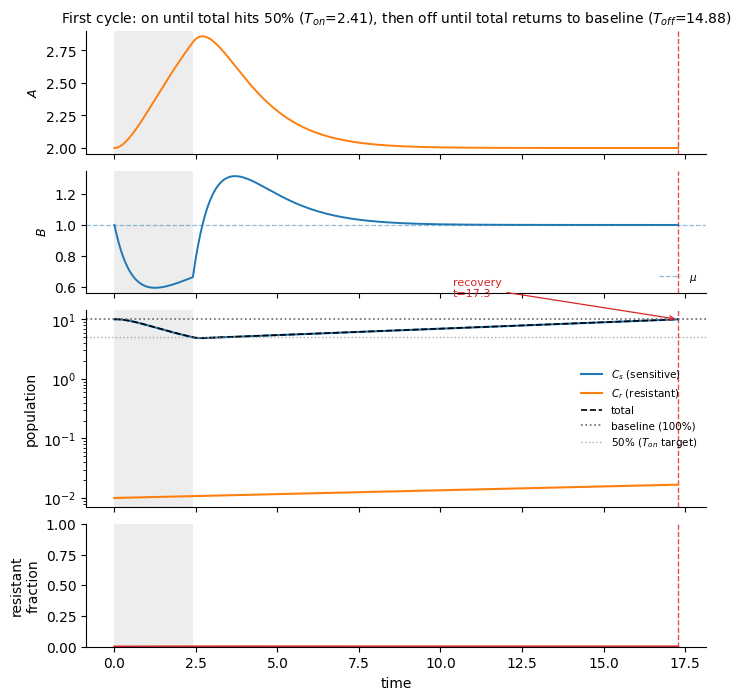

In [15]:
# --- verbose plot of the first cycle: on-phase (treat to 50%) + measured recovery off-phase ---
t_cycle = np.concatenate([sol_on.t, sol_off.t + Ton_opt])
y_cycle = np.concatenate([sol_on.y, sol_off.y], axis=1)
A_c, B_c, Cs_c, Cr_c = y_cycle
total_c   = Cs_c + Cr_c
t_recover = Ton_opt + T_off_recovery

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw={'hspace': 0.12, 'height_ratios': [1, 1, 1.6, 1]})
for ax in axes:
    ax.axvspan(0, Ton_opt, color='lightgray', alpha=0.4, lw=0)         # on-phase
    ax.axvline(t_recover, color='C3', ls='--', lw=1.0, alpha=0.8)      # recovery point
    sns.despine(ax=ax)

axes[0].plot(t_cycle, A_c, color='C1', lw=1.4)
axes[0].set_ylabel('$A$', fontsize=9)

axes[1].plot(t_cycle, B_c, color='C0', lw=1.4)
axes[1].axhline(mu_, color='C0', ls='--', lw=0.9, alpha=0.5, label=r'$\mu$')
axes[1].set_ylabel('$B$', fontsize=9)
axes[1].legend(fontsize=7.5, frameon=False, loc='lower right')

axes[2].plot(t_cycle, Cs_c, label='$C_s$ (sensitive)')
axes[2].plot(t_cycle, Cr_c, label='$C_r$ (resistant)')
axes[2].plot(t_cycle, total_c, color='k', ls='--', lw=1.2, label='total')
axes[2].axhline(baseline, color='0.4', ls=':', lw=1.2, label='baseline (100%)')
axes[2].axhline(0.5 * baseline, color='0.6', ls=':', lw=1.0, alpha=0.8, label='50% ($T_{on}$ target)')
axes[2].set_ylabel('population')
axes[2].set_yscale('log')
axes[2].legend(fontsize=7.5, frameon=False, loc='center right')
axes[2].annotate(f'recovery\nt={t_recover:.1f}', xy=(t_recover, baseline),
                 xytext=(t_recover * 0.6, baseline * 2.4), fontsize=8, color='C3',
                 arrowprops=dict(arrowstyle='->', color='C3', lw=0.9))

axes[3].plot(t_cycle, Cr_c / total_c, color='C3')
axes[3].set_ylabel('resistant\nfraction')
axes[3].set_ylim(0, 1)
axes[3].set_xlabel('time')

axes[0].set_title(f'First cycle: on until total hits 50% ($T_{{on}}$={Ton_opt:.2f}), then off until '
                  f'total returns to baseline ($T_{{off}}$={T_off_recovery:.2f})', fontsize=10)
plt.tight_layout()
plt.show()

### Step 2 — apply the frozen recovery $T_{off}$ over the full horizon

Now run the full intermittent schedule with $T_{on}=T_{on}^{opt}$ and the fixed $T_{off}$ measured above. Because the recovery time was calibrated on cycle 1 (when $C_r\approx0$), watch whether later cycles start **overshooting** the baseline: as $C_r$ grows it also contributes to regrowth, so the tumor reaches baseline *sooner* than the frozen $T_{off}$ allows — the once-measured value goes stale as composition drifts.

/tmp/ipykernel_2909079/3988154356.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


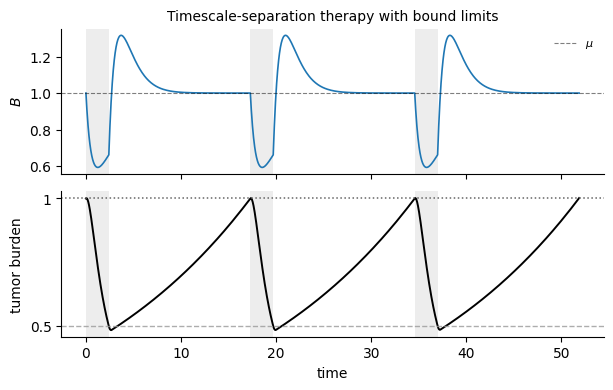

3 cycles over horizon 60;  period = 17.29

per-cycle total burden at each off-phase end (calibrated to sit at baseline early;
drifts above as the untouched Cr grows):
  cycle  1: total(t=  17.3) =  10.0100  ( 100.0% baseline,  resist frac 0.002)
  cycle  2: total(t=  34.6) =  10.0146  ( 100.0% baseline,  resist frac 0.003)
  cycle  3: total(t=  51.9) =  10.0266  ( 100.2% baseline,  resist frac 0.005)

min total = 4.849 at t=2.6
final (t=52): total=10.03, resist frac=0.0047, time to progression=None


In [16]:
T_horizon = 60.0
period    = Ton_opt + T_off_recovery
n_cycles  = int(T_horizon // period)
on_ranges = periodic_on_ranges(Ton_opt, T_off_recovery, n_cycles)

t_run, y_run = simulation.simulate_rpa_intermittent(
    model, 'b1', b1_on, b1, t_on=Ton_opt, t_off=T_off_recovery,
    n_cycles=n_cycles, y0=y0, plot=False)

Cs_run, Cr_run = y_run[2], y_run[3]
total_run = Cs_run + Cr_run
ttp_run   = time_to_progression(t_run, total_run, baseline)

# compact plot: B and total population only
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, gridspec_kw={'hspace': 0.12})
for ax in axes:
    for t0, t1 in on_ranges:
        ax.axvspan(t0, t1, color='lightgray', alpha=0.4, lw=0)
    sns.despine(ax=ax)
axes[0].plot(t_run, y_run[1], color='C0', lw=1.2)
axes[0].axhline(mu_, color='k', ls='--', lw=0.8, alpha=0.5, label=r'$\mu$')
axes[0].set_ylabel('$B$')
axes[0].legend(fontsize=8, frameon=False, loc='upper right')
axes[1].plot(t_run, total_run, color='k', lw=1.4)
axes[1].axhline(baseline, color='0.4', ls=':', lw=1.1)
axes[1].axhline(0.5 * baseline, color='0.6', ls='--', lw=1.0, alpha=0.8)
axes[1].set_yticks([0.5 * baseline, baseline])
axes[1].set_yticklabels(['0.5', '1'])
axes[1].set_ylabel('tumor burden')
axes[1].set_xlabel('time')
axes[0].set_title(f'Timescale-separation therapy with bound limits'
                  , fontsize=10)
plt.tight_layout()
plt.show()

print(f'{n_cycles} cycles over horizon {T_horizon:.0f};  period = {period:.2f}\n')
print('per-cycle total burden at each off-phase end (calibrated to sit at baseline early;')
print('drifts above as the untouched Cr grows):')
for c in range(n_cycles):
    idx = np.argmin(np.abs(t_run - (c + 1) * period))
    print(f'  cycle {c + 1:2d}: total(t={t_run[idx]:6.1f}) = {total_run[idx]:8.4f}  '
          f'({100 * total_run[idx] / baseline:6.1f}% baseline,  resist frac {Cr_run[idx] / total_run[idx]:.3f})')
print(f'\nmin total = {total_run.min():.4g} at t={t_run[total_run.argmin()]:.1f}')
print(f'final (t={t_run[-1]:.0f}): total={total_run[-1]:.4g}, '
      f'resist frac={Cr_run[-1] / total_run[-1]:.4f}, time to progression={ttp_run}')

### Comparison — recovery-based $T_{off}$ vs. the old fixed $T_{off}=10$

Same model, same $T_{on}^{opt}$, same initial condition and horizon — only the off-rule differs. The recovery schedule uses a much longer off-phase (lower duty cycle / less drug) and *contains* the tumor near baseline, whereas the short fixed $T_{off}=10$ keeps driving total burden down (until clonal selection relapses it).

/tmp/ipykernel_2909079/4116415400.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


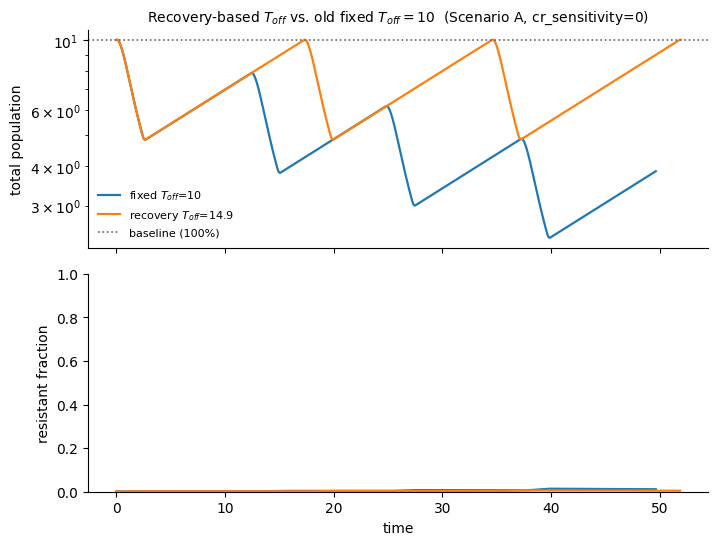

schedule             duty   min total  final total  final resist frac  time to prog
fixed T_off=10      0.194        2.38        3.857             0.0114         never
recovery T_off=14.9  0.139       4.849        10.03             0.0047         never


In [17]:
# old fixed-Toff schedule, same T_on and horizon
n_cycles_ref  = int(T_horizon // (Ton_opt + T_off_ref))
t_ref, y_ref  = simulation.simulate_rpa_intermittent(
    model, 'b1', b1_on, b1, t_on=Ton_opt, t_off=T_off_ref,
    n_cycles=n_cycles_ref, y0=y0, plot=False)
total_ref = y_ref[2] + y_ref[3]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'hspace': 0.12})
axes[0].plot(t_ref, total_ref, lw=1.6, label=f'fixed $T_{{off}}$={T_off_ref:.0f}')
axes[0].plot(t_run, total_run, lw=1.6, label=f'recovery $T_{{off}}$={T_off_recovery:.1f}')
axes[0].axhline(baseline, color='0.4', ls=':', lw=1.2, label='baseline (100%)')
axes[0].set_yscale('log')
axes[0].set_ylabel('total population')
axes[0].legend(fontsize=8, frameon=False)
sns.despine(ax=axes[0])

axes[1].plot(t_ref, y_ref[3] / total_ref, lw=1.6)
axes[1].plot(t_run, Cr_run / total_run, lw=1.6)
axes[1].set_ylabel('resistant fraction')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('time')
sns.despine(ax=axes[1])

axes[0].set_title('Recovery-based $T_{off}$ vs. old fixed $T_{off}=10$  (Scenario A, cr_sensitivity=0)',
                  fontsize=10)
plt.tight_layout()
plt.show()

ttp_ref = time_to_progression(t_ref, total_ref, baseline)
print(f'{"schedule":18s} {"duty":>6s} {"min total":>11s} {"final total":>12s} '
      f'{"final resist frac":>18s} {"time to prog":>13s}')
for label, Ton, Toff, total, Cr, ttp in [
    (f'fixed T_off={T_off_ref:.0f}',      Ton_opt, T_off_ref,      total_ref, y_ref[3], ttp_ref),
    (f'recovery T_off={T_off_recovery:.1f}', Ton_opt, T_off_recovery, total_run, Cr_run,  ttp_run),
]:
    duty    = Ton / (Ton + Toff)
    ttp_str = f'{ttp:13.1f}' if ttp is not None else f'{"never":>13s}'
    print(f'{label:18s} {duty:6.3f} {total.min():11.4g} {total[-1]:12.4g} '
          f'{Cr[-1] / total[-1]:18.4f} {ttp_str}')

## Resonance therapy: maintaining tumor burden by gating a pumped homeostatic oscillation

The sections above dose the drug by *pulsing $b_1$* (timescale separation). **Resonance therapy** (Figure 2) treats differently — by *parametrically switching the spring constant* of the $A,B$ homeostatic loop. Written as a damped oscillator, $\ddot B + \beta_2\dot B + \alpha\beta_1 (B-\mu)=0$, the spring constant is $k=\alpha\beta_1$. Switching $\alpha$ **hard** ($\alpha_{hard}=50$) while $B$ returns toward $\mu$ and **soft** ($\alpha_{soft}=10$) while it departs *pumps* the oscillation (parametric resonance), driving $B$ into large swings. Every excursion below $\mu$ kills the sensitive clone $C_s$ (kill $=c_2\max(\mu-B,0)$).

We use Figure 2's AB parameters ($\beta_1=\beta_2=1$, $\mu=1$) with the clonal tumor from Scenario A ($r_s=0.05$, $r_r=0.03$, $c_2=1$, **complete resistance** `cr_sensitivity=0`).

Two practical ingredients make this into a *containment* controller:
- **Amplitude cap.** The pure pump is *divergent* (amplitude grows without bound and blows up numerically). We pump only while $|B-\mu|<0.5$ and otherwise let the spring relax — a bounded, physical oscillation.
- **Burden gate.** We *monitor total tumor size* and **halt** resonance (hold $\alpha=\alpha_{off}=5$, a plain damped spring, so $B$ relaxes toward $\mu$ and the tumor regrows) once burden drops to **50%** of its initial value, then **restart** resonance once burden regrows to **90%**. Because the off-spring only *partly* relaxes $B$ before the tumor recovers, the leftover displacement (mostly in $A$) re-seeds the pump at each restart — no artificial kick needed.

In [18]:
# --- Resonance therapy on the AB loop: parametric alpha-switching (Figure 2) ---
mu = 1.0   # homeostatic setpoint B* = mu (same as B_ss)

def adaptive_alpha(B, Bdot, a_hard, a_soft, eq=mu):
    """Figure-2 resonance rule: hard spring while B returns toward eq, soft while it departs."""
    if B > eq:
        return a_hard if Bdot < 0 else a_soft
    return a_hard if Bdot > 0 else a_soft

def rk4_step(f, y, dt):
    k1 = f(y); k2 = f(y + 0.5*dt*k1); k3 = f(y + 0.5*dt*k2); k4 = f(y + dt*k3)
    return y + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def resonance_clonal_rhs(y, alpha, beta1, beta2, r_s, r_r, K, c2, cr_sens):
    """AB homeostatic loop (spring constant alpha*beta1) driving a two-clone tumor:
    Cs killed while B<mu, Cr killed at cr_sens x that rate, logistic competition."""
    A, B, Cs, Cr = y
    kill = c2 * max(mu - B, 0.0)
    gf   = 1.0 - (Cs + Cr) / K
    return np.array([alpha * (mu - B),
                     beta1 * A - beta2 * B,
                     r_s * Cs * gf - kill * Cs,
                     r_r * Cr * gf - cr_sens * kill * Cr])

def simulate_resonance_gated(y0, T, dt=0.005, beta1=1.0, beta2=1.0,
                             a_hard=50.0, a_soft=10.0, alpha_off=10.0, amp_cap=0.5,
                             r_s=0.05, r_r=0.03, K=1000.0, c2=1.0, cr_sens=0.0,
                             off_frac=0.5, on_frac=0.7):
    """Fixed-step RK4. The capped alpha-pump runs while 'treating'; halt (hold
    alpha_off) once burden <= off_frac*baseline, restart once burden >= on_frac*baseline.
    Returns t, y (4 x N), alpha(t), treating(t) mask, event list, baseline."""
    y0 = np.asarray(y0, float)
    baseline = y0[2] + y0[3]
    n = int(round(T / dt)); t = np.linspace(0, T, n + 1)
    y = np.zeros((n + 1, 4)); y[0] = y0
    alpha_t = np.zeros(n + 1); treat = np.zeros(n + 1, dtype=bool)
    treating = True; events = []
    for i in range(n):
        A, B, Cs, Cr = y[i]; burden = Cs + Cr
        if treating and burden <= off_frac * baseline:
            treating = False; events.append(('halt', t[i]))
        elif (not treating) and burden >= on_frac * baseline:
            treating = True; events.append(('restart', t[i]))
        treat[i] = treating
        Bdot = beta1 * A - beta2 * B
        if treating and abs(B - mu) < amp_cap:
            ai = adaptive_alpha(B, Bdot, a_hard, a_soft)   # pump (below amplitude cap)
        else:
            ai = alpha_off                                  # damped spring: off, or cap reached
        alpha_t[i] = ai
        y[i + 1] = rk4_step(lambda z: resonance_clonal_rhs(z, ai, beta1, beta2,
                            r_s, r_r, K, c2, cr_sens), y[i], dt)
    alpha_t[-1] = alpha_t[-2]; treat[-1] = treat[-2]
    return t, y.T, alpha_t, treat, events, baseline

In [19]:
# complete resistance (cr_sensitivity=0), Figure-2 AB params, Scenario-A tumor rates
Cs0_res, Cr0_res = 10.0, 0.01
y0_res  = np.array([1.0, 0.0, Cs0_res, Cr0_res])   # seed cycle 1 with B displaced to 0
T_res   = 100.0
off_frac_res, on_frac_res = 0.6, 0.7               # CONTROL thresholds: halt at 60%, restart at 90%

t_res, y_res, alpha_res, treat_res, events_res, base_res = simulate_resonance_gated(
    y0_res, T=T_res, dt=0.005, cr_sens=0.0, off_frac=off_frac_res, on_frac=on_frac_res)

A_res, B_res, Cs_res, Cr_res = y_res
total_res = Cs_res + Cr_res
ttp_res   = time_to_progression(t_res, total_res, base_res)

n_halt  = sum(1 for k, _ in events_res if k == 'halt')
n_start = sum(1 for k, _ in events_res if k == 'restart')
print(f'baseline = {base_res:.2f};  halt <= {off_frac_res*base_res:.2f} ({off_frac_res*100:.0f}%),  '
      f'restart >= {on_frac_res*base_res:.2f} ({on_frac_res*100:.0f}%)')
print(f'{n_halt} halts, {n_start} restarts;  resonance duty = {treat_res.mean():.3f}')
print(f'B range [{B_res.min():.3f}, {B_res.max():.3f}]  (bounded & physical, mu={mu})')
print('event times:', [(k, round(tt, 1)) for k, tt in events_res])
print(f'total burden ranges {100*total_res.min()/base_res:.0f}% .. {100*total_res.max()/base_res:.0f}% of baseline')
print(f'final (t={T_res:.0f}): total = {total_res[-1]:.4g} ({100*total_res[-1]/base_res:.0f}%), '
      f'resist frac = {Cr_res[-1]/total_res[-1]:.4f}, time to progression = {ttp_res}')

baseline = 10.01;  halt <= 6.01 (60%),  restart >= 7.01 (70%)
4 halts, 4 restarts;  resonance duty = 0.442
B range [0.000, 1.977]  (bounded & physical, mu=1.0)
event times: [('halt', np.float64(1.9)), ('restart', np.float64(17.0)), ('halt', np.float64(29.0)), ('restart', np.float64(42.9)), ('halt', np.float64(54.3)), ('restart', np.float64(67.9)), ('halt', np.float64(79.6)), ('restart', np.float64(92.8))]
total burden ranges 43% .. 100% of baseline
final (t=100): total = 9.527 (95%), resist frac = 0.0207, time to progression = None


/tmp/ipykernel_2909079/3342486852.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


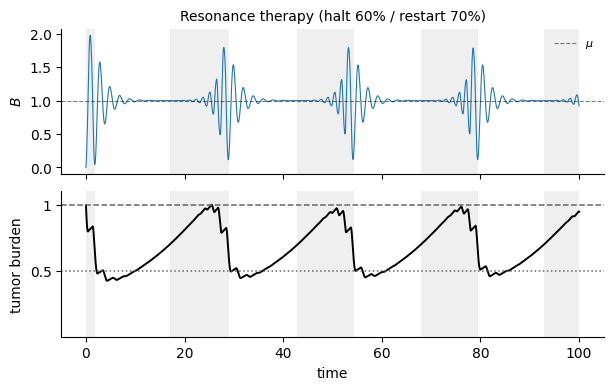

In [21]:
# resonance-active intervals (for shading)
ti   = treat_res.astype(int)
ch   = np.where(np.diff(ti) != 0)[0]
bnds = np.concatenate([[0], ch + 1, [len(t_res) - 1]])
on_ranges_res = [(t_res[bnds[j]], t_res[bnds[j + 1]])
                 for j in range(len(bnds) - 1) if ti[bnds[j]] == 1]

# DISPLAY reference lines only -- independent of the control thresholds (off_frac_res/on_frac_res)
disp_lo, disp_hi = 0.5, 1.0

# compact plot: B and total population only (linear axis)
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, gridspec_kw={'hspace': 0.12})
for ax in axes:
    for t0, t1 in on_ranges_res:
        ax.axvspan(t0, t1, color='lightgray', alpha=0.35, lw=0)
    sns.despine(ax=ax)

axes[0].plot(t_res, B_res, color='C0', lw=0.8)
axes[0].axhline(mu, color='k', ls='--', lw=0.8, alpha=0.5, label=r'$\mu$')
axes[0].set_ylabel('$B$')
axes[0].legend(fontsize=8, frameon=False, loc='upper right')

axes[1].plot(t_res, total_res, color='k', lw=1.4)
axes[1].axhline(disp_hi * base_res, color='0.4', ls='--', lw=1.1)
axes[1].axhline(disp_lo * base_res, color='0.4', ls=':',  lw=1.1)
axes[1].set_ylim(0, 1.1 * total_res.max())
axes[1].set_yticks([disp_lo * base_res, disp_hi * base_res])
axes[1].set_yticklabels(['0.5', '1'])
axes[1].set_ylabel('tumor burden')
axes[1].set_xlabel('time')

axes[0].set_title(f'Resonance therapy (halt {off_frac_res*100:.0f}% / '
                  f'restart {on_frac_res*100:.0f}%)', fontsize=10)
plt.tight_layout()
plt.show()

**Takeaway.** Burden-gated resonance therapy *contains* the tumor: it halts at 60% and restarts at 90% (the plot's 50%/100% lines are display references only), holding total burden near baseline over the window while keeping $B$'s pumped oscillation **bounded and physical** ($B\in[0,2]$, thanks to the amplitude cap). Containment isn't tight — from the small residual seed the pump needs a few oscillations to spin up, so total overshoots to $\approx 2\times$ baseline before each burst catches it — but it never runs away here. The re-seeding works exactly as expected: the off-spring only partly relaxes the loop, so the residual displacement (mostly in $A$) restarts the pump each cycle with no artificial kick.

Underneath, with **complete resistance** the untouched clone $C_r$ is selected on that same schedule — each pumped burst suppresses $C_s$ and vacates capacity for $C_r$, so the resistant fraction creeps up from its rare seed every cycle. Over this short horizon it is still small, but on longer horizons $C_r$ takes over, the gate can no longer pull total below 60%, and the tumor escapes to carrying capacity — the **same clonal-selection relapse** as the timescale-separation sections. Swapping the dosing mechanism ($b_1$ pulsing → parametric $\alpha$-resonance) changes the *how*, not that conclusion.